Import Model Configuration
==========================

In [1]:
import yaml

model_cfg = "maskrcnn_resnet50_fpn.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'maskrcnn_resnet50_fpn'

Dataset Class
=============

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann:
                continue

            rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
            mask = coco_mask.decode(rles)
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

            # ⚠️ Filter out zero-area boxes *after transforms*
            boxes = target["boxes"]
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])

            # Apply keep mask to all fields
            target["boxes"] = tv_tensors.BoundingBoxes(boxes[keep], format="XYXY", canvas_size=img.shape[-2:])
            target["labels"] = target["labels"][keep]
            if "masks" in target:
                target["masks"] = target["masks"][keep]
            if "area" in target:
                target["area"] = target["area"][keep]
            if "iscrowd" in target:
                target["iscrowd"] = target["iscrowd"][keep]

        return img, target

    def __len__(self):
        return len(self.ids)


Augmentiations
=============

In [3]:
from torchvision.transforms import v2 as T
import torch

def get_transform(train: bool):
    if train:
        transforms = [
            T.RandomPhotometricDistort(),  # Color jitter
            T.Resize((512, 512)),          # Fixed resize for stability
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10, fill=0, expand=False),  # Limit rotation area
            # T.RandomZoomOut(fill=0, p=0.3),  # Optional — leave off for now
            # T.RandomCrop((512, 512), pad_if_needed=False, fill=0),  # Only if images are bigger
        ]
        '''
        transforms = [
            T.RandomPhotometricDistort(),                           # Color jitter (safe for segmentation)
            T.RandomChoice([
                T.Resize(400),
                T.Resize(512),
                T.Resize(640),
            ]),                                                     # Random scale resize
            T.RandomCrop((512, 512), pad_if_needed=True, fill=0),   # Crop with padding
            T.RandomHorizontalFlip(p=0.5),                          # Horizontal flip
            T.RandomZoomOut(fill=0, p=0.5),                         # Random zoom out with black pad
            T.RandomRotation(degrees=10, fill=0),                   # Random rotation ±10 degrees with black fill
        ]
        '''
    else:
        transforms = [
            T.Resize((512, 512)),                                   # Consistent resize for val/test
        ]

    transforms += [
        T.ToDtype(torch.float32, scale=True),                       # Convert image to float32 in [0, 1]
        T.ToPureTensor(),                                           # Convert to torch.Tensor (Image, Mask, BBoxes)
    ]

    return T.Compose(transforms)

Log Hyperparams to TensorBoard
===============================

In [4]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import shutil, os

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

log_dir = f"runs/{cfg['experiment_name']}_{timestamp}"

if os.path.exists(log_dir):
    shutil.rmtree(log_dir)

# Save cfg as hyperparameters (flatten dictionary)
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

writer = SummaryWriter(log_dir=f"runs/{cfg['experiment_name']}_{timestamp}")

# Option 1: Save flattened cfg to TensorBoard as hparams
flattened_cfg = flatten_dict(cfg)

# Option 2: Also log as text (for easier reading)
cfg_text = yaml.dump(cfg, sort_keys=False)
writer.add_text("config", f"```yaml\n{cfg_text}\n```")


Train
=====

In [5]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate

from tqdm import tqdm
import sys
import time

from models import MODEL_REGISTRY



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# COCO-style dataset using your structure
dataset = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/train",
    transforms=get_transform(train=True)
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/valid",
    transforms=get_transform(train=False)
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/test",
    transforms=get_transform(train=False)
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers=4,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    collate_fn=utils.collate_fn
)

# Two classes: background + foreground
num_classes = cfg['num_classes']

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
#model = get_model_instance_segmentation(num_classes)

model.to(device)

# Optimizer and LR scheduler from config
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=cfg["train"]["lr"],
    momentum=cfg["train"]["momentum"],
    weight_decay=cfg["train"]["weight_decay"],
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg["train"]["lr_step_size"],
    gamma=cfg["train"]["gamma"],
)


num_epochs = cfg['train']['epochs']
print("Start training...")

#scaler = torch.cuda.amp.GradScaler()  # Enable AMP if you want (optional)
scaler = torch.amp.GradScaler()  # Updated for modern AMP


cfg["output_dir"] = f"outputs/{cfg['experiment_name']}_{timestamp}"
os.makedirs(cfg["output_dir"], exist_ok=True)

best_val = -float("inf")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    sys.stdout.flush()

    start_time = time.time()

    # tqdm-wrapped version of the training loop
    model.train()
    metric_logger = utils.MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", utils.SmoothedValue(window_size=1, fmt="{value:.6f}"))

    header = f"Epoch: [{epoch}]"

    # Optional warmup scheduler for the first epoch
    warmup_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for batch_idx, (images, targets) in enumerate(tqdm(data_loader, desc=header)):
        images = list(img.to(device) for img in images)
        #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Mixed precision (optional)
        #with torch.cuda.amp.autocast(enabled=False):  # Set to True to enable AMP
        with torch.amp.autocast(device_type='cuda', enabled=False):  # Set to True to enable AMP
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # Check for NaN or inf loss
        if not torch.isfinite(losses):
            print(f"[!] Loss is {losses.item()}, stopping training")
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        # AMP (uncomment if you enable autocast)
        # scaler.scale(losses).backward()
        # scaler.step(optimizer)
        # scaler.update()

        losses.backward()
        optimizer.step()

        if warmup_scheduler is not None:
            warmup_scheduler.step()

        metric_logger.update(loss=losses.item(), **loss_dict)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

        # Log to TensorBoard
        global_step = epoch * len(data_loader) + batch_idx
        writer.add_scalar("Train/Loss", losses.item(), global_step)
        writer.add_scalar("Train/LR", optimizer.param_groups[0]["lr"], global_step)

    lr_scheduler.step()
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} completed in {epoch_time:.2f} seconds.")
    


    # Validation
    print("Evaluating on validation set:")
    coco_evaluator = evaluate(model, data_loader_valid, device=device)

    # Extract segmentation (IoU type: 'segm') metrics
    segm_eval = coco_evaluator.coco_eval["segm"]
    segm_stats = segm_eval.stats  # List of 12 standard COCO segmentation metrics

    # Log COCO-style mAP scores for segmentation
    writer.add_scalar("Val/segm_mAP", segm_stats[0], epoch)
    writer.add_scalar("Val/segm_mAP_50", segm_stats[1], epoch)
    writer.add_scalar("Val/segm_mAP_75", segm_stats[2], epoch)
    writer.add_scalar("Val/segm_mAP_small", segm_stats[3], epoch)
    writer.add_scalar("Val/segm_mAP_medium", segm_stats[4], epoch)
    writer.add_scalar("Val/segm_mAP_large", segm_stats[5], epoch)

    # Use segm mAP as your validation score
    current_val = segm_stats[0]  # mAP @ IoU=.50:.95 (primary COCO metric)

    # Create output directory if it doesn't exist
    os.makedirs(cfg["output_dir"], exist_ok=True)

    if current_val > best_val:  # For mAP, higher is better
        best_val = current_val

        # Save model weights
        torch.save(model.state_dict(), os.path.join(cfg["output_dir"], "model_best.pth"))

        # Optionally: save full checkpoint (model + optimizer + scheduler + epoch)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'lr_scheduler_state_dict': lr_scheduler.state_dict(),
        }, os.path.join(cfg["output_dir"], "checkpoint_best.pth"))


print("\nThat's it!")

loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Train size: 1049
Validation size: 300
Test size: 150
Start training...

Epoch 1/10


Epoch: [0]: 100%|██████████| 525/525 [05:33<00:00,  1.58it/s]


Epoch 1 completed in 333.15 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:58  model_time: 0.4458 (0.4458)  evaluator_time: 0.0206 (0.0206)  time: 0.5965  data: 0.1263  max mem: 2293
Test:  [100/300]  eta: 0:00:34  model_time: 0.1448 (0.1490)  evaluator_time: 0.0102 (0.0164)  time: 0.1739  data: 0.0045  max mem: 2293
Test:  [200/300]  eta: 0:00:17  model_time: 0.1288 (0.1482)  evaluator_time: 0.0058 (0.0176)  time: 0.1661  data: 0.0046  max mem: 2293
Test:  [299/300]  eta: 0:00:00  model_time: 0.1271 (0.1451)  evaluator_time: 0.0054 (0.0166)  time: 0.1449  data: 0.0043  max mem: 2293
Test: Total time: 0:00:50 (0.1684 s / it)
Averaged stats: model_time: 0.1271 (0.1451)  evaluator_time: 0.0054 (0.0166)
Accumulating evaluation results...
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.811
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [1]: 100%|██████████| 525/525 [05:45<00:00,  1.52it/s]


Epoch 2 completed in 345.39 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:04  model_time: 0.4475 (0.4475)  evaluator_time: 0.0118 (0.0118)  time: 0.6155  data: 0.1523  max mem: 2303
Test:  [100/300]  eta: 0:00:32  model_time: 0.1290 (0.1374)  evaluator_time: 0.0099 (0.0158)  time: 0.1610  data: 0.0048  max mem: 2303
Test:  [200/300]  eta: 0:00:16  model_time: 0.1157 (0.1378)  evaluator_time: 0.0047 (0.0175)  time: 0.1597  data: 0.0045  max mem: 2303
Test:  [299/300]  eta: 0:00:00  model_time: 0.1181 (0.1351)  evaluator_time: 0.0052 (0.0166)  time: 0.1376  data: 0.0046  max mem: 2303
Test: Total time: 0:00:47 (0.1582 s / it)
Averaged stats: model_time: 0.1181 (0.1351)  evaluator_time: 0.0052 (0.0166)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.809
 Average Precision  (AP) @[ IoU=0.50  

...

Epoch 8 completed in 345.31 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:40  model_time: 0.3503 (0.3503)  evaluator_time: 0.0131 (0.0131)  time: 0.5343  data: 0.1666  max mem: 2305
Test:  [100/300]  eta: 0:00:34  model_time: 0.1280 (0.1480)  evaluator_time: 0.0131 (0.0174)  time: 0.1638  data: 0.0046  max mem: 2305
Test:  [200/300]  eta: 0:00:17  model_time: 0.1183 (0.1475)  evaluator_time: 0.0054 (0.0190)  time: 0.1581  data: 0.0044  max mem: 2305
Test:  [299/300]  eta: 0:00:00  model_time: 0.1213 (0.1456)  evaluator_time: 0.0058 (0.0179)  time: 0.1413  data: 0.0045  max mem: 2305
Test: Total time: 0:00:51 (0.1704 s / it)
Averaged stats: model_time: 0.1213 (0.1456)  evaluator_time: 0.0058 (0.0179)
Accumulating evaluation results...
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.852
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [8]: 100%|██████████| 525/525 [05:37<00:00,  1.56it/s]


Epoch 9 completed in 337.54 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:03  model_time: 0.4338 (0.4338)  evaluator_time: 0.0124 (0.0124)  time: 0.6102  data: 0.1603  max mem: 2315
Test:  [100/300]  eta: 0:00:37  model_time: 0.1348 (0.1639)  evaluator_time: 0.0112 (0.0169)  time: 0.1722  data: 0.0048  max mem: 2315
Test:  [200/300]  eta: 0:00:19  model_time: 0.1442 (0.1641)  evaluator_time: 0.0054 (0.0187)  time: 0.1799  data: 0.0047  max mem: 2315
Test:  [299/300]  eta: 0:00:00  model_time: 0.1230 (0.1625)  evaluator_time: 0.0055 (0.0180)  time: 0.1431  data: 0.0044  max mem: 2315
Test: Total time: 0:00:56 (0.1878 s / it)
Averaged stats: model_time: 0.1230 (0.1625)  evaluator_time: 0.0055 (0.0180)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.858
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [9]: 100%|██████████| 525/525 [05:32<00:00,  1.58it/s]


Epoch 10 completed in 332.44 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:31  model_time: 0.3283 (0.3283)  evaluator_time: 0.0129 (0.0129)  time: 0.5045  data: 0.1600  max mem: 2315
Test:  [100/300]  eta: 0:00:36  model_time: 0.1260 (0.1596)  evaluator_time: 0.0108 (0.0167)  time: 0.1611  data: 0.0042  max mem: 2315
Test:  [200/300]  eta: 0:00:18  model_time: 0.1160 (0.1586)  evaluator_time: 0.0045 (0.0180)  time: 0.1528  data: 0.0044  max mem: 2315
Test:  [299/300]  eta: 0:00:00  model_time: 0.1151 (0.1570)  evaluator_time: 0.0051 (0.0173)  time: 0.1340  data: 0.0041  max mem: 2315
Test: Total time: 0:00:54 (0.1812 s / it)
Averaged stats: model_time: 0.1151 (0.1570)  evaluator_time: 0.0051 (0.0173)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.853
 Average Precision  (AP) @[ IoU=0.50 

In [7]:
# === Log hyperparameters and final validation metric ===
from torch.utils.tensorboard import SummaryWriter

flattened_cfg = flatten_dict(cfg)

writer.add_hparams(
    hparam_dict=flattened_cfg,
    metric_dict={"Val/best_mAP": best_val}
)

writer.close()

Test (Example)
=====

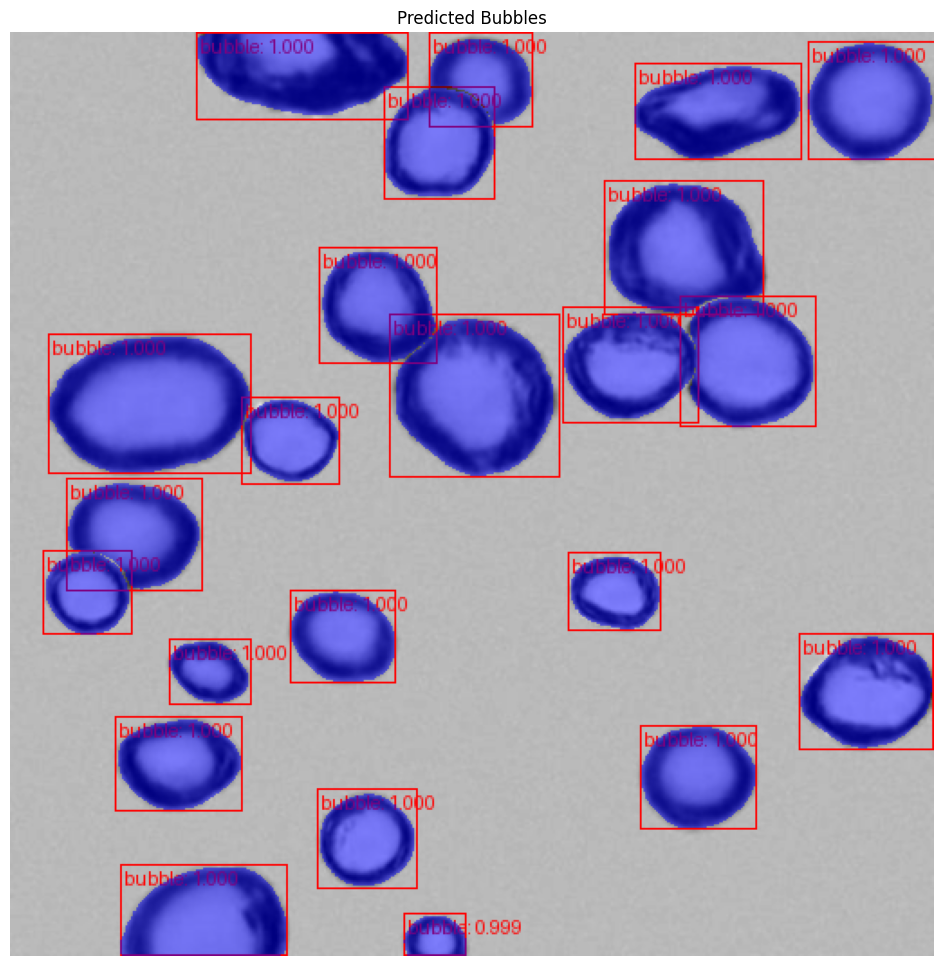

In [10]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torch

image = read_image("../../../BubANN_GAN.v1i.coco-segmentation/test/BubGAN_0002_jpg.rf.a78f79c439aaf0c4cfcaac4ce751a071.jpg")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to(device)

    predictions = model([x])
    pred = predictions[0]

# Prepare image for visualization (use x)
vis_img = (255.0 * (x.cpu() - x.cpu().min()) / (x.cpu().max() - x.cpu().min())).to(torch.uint8)
vis_img = vis_img[:3, ...]

pred_labels = [f"bubble: {score:.3f}" for score in pred["scores"]]
pred_boxes = pred["boxes"].cpu().long()
masks = (pred["masks"].cpu() > 0.7).squeeze(1)

output_image = draw_bounding_boxes(vis_img, pred_boxes, pred_labels, colors="red")
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")
plt.title("Predicted Bubbles")
plt.show()

Load Model Checkpoint (Example)
====================

In [ ]:
'''
model.load_state_dict(torch.load("outputs/maskrcnn_baseline/model_epoch_3.pth"))
model.to(device)
model.eval()

or

model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
model.load_state_dict(torch.load("model_best.pth"))
model.to(device)
model.eval()
'''

'\nmodel.load_state_dict(torch.load("outputs/maskrcnn_baseline/model_epoch_3.pth"))\nmodel.to(device)\nmodel.eval()\n'

Resume Training from Checkpoint (Example)
==========================================

In [ ]:
'''
checkpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']

or

checkpoint = torch.load("checkpoint_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']
'''

'\ncheckpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")\nmodel.load_state_dict(checkpoint[\'model_state_dict\'])\noptimizer.load_state_dict(checkpoint[\'optimizer_state_dict\'])\nlr_scheduler.load_state_dict(checkpoint[\'lr_scheduler_state_dict\'])\nstart_epoch = checkpoint[\'epoch\']\n'

Test Batch
=========

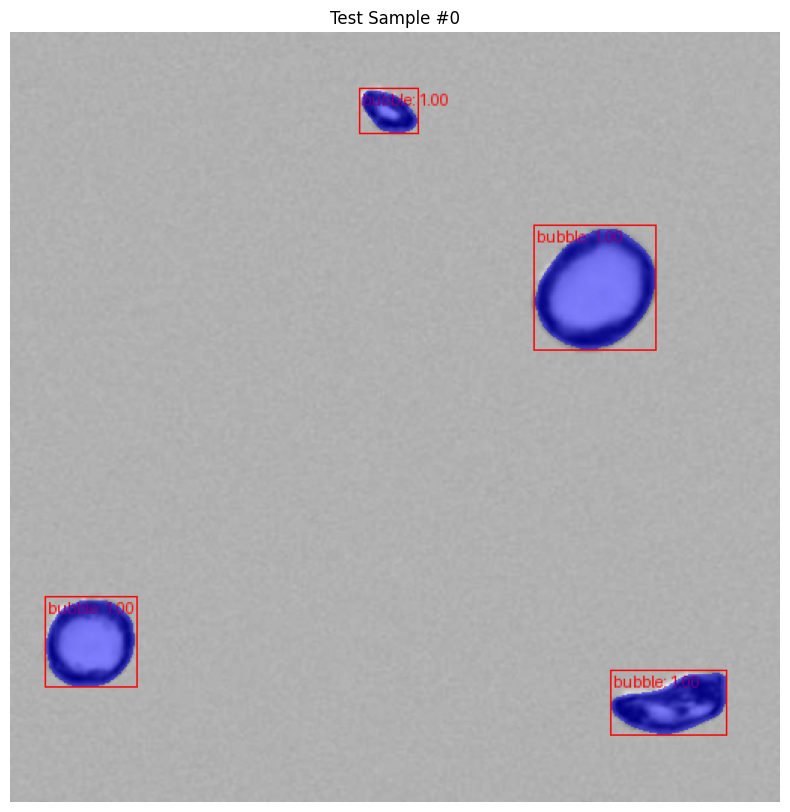

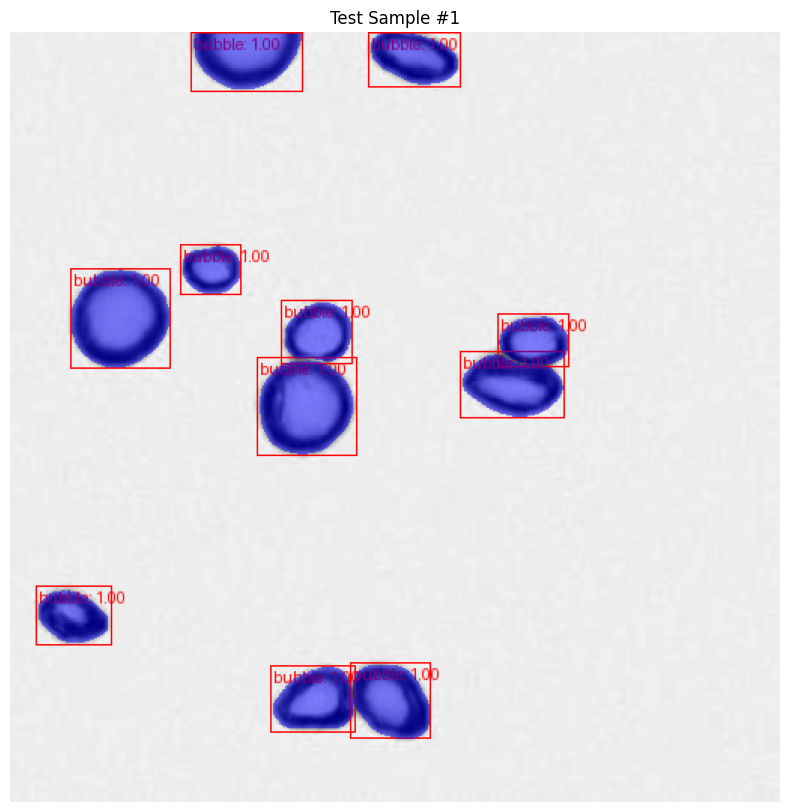

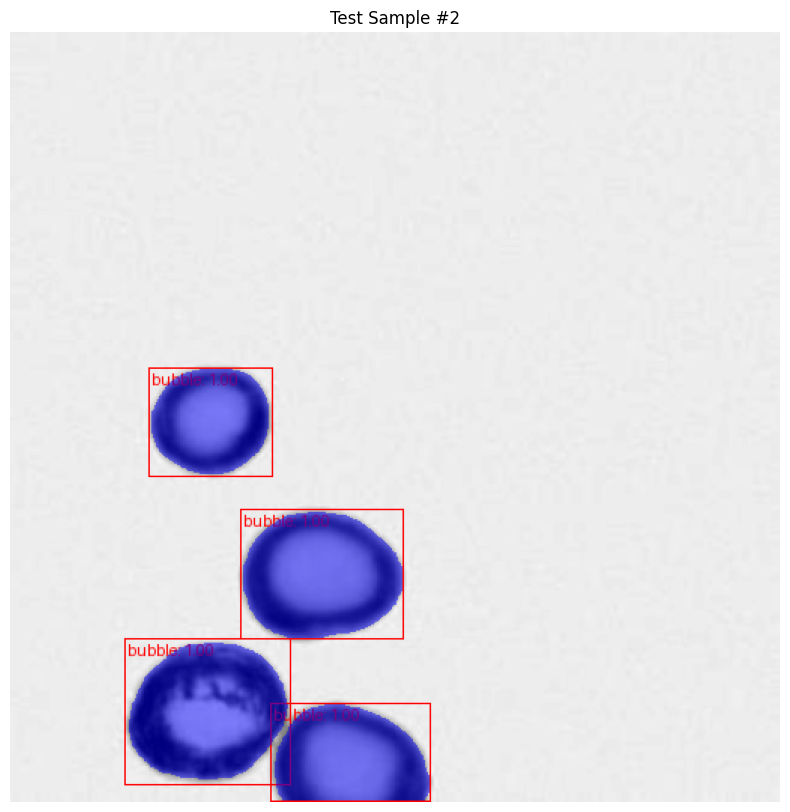

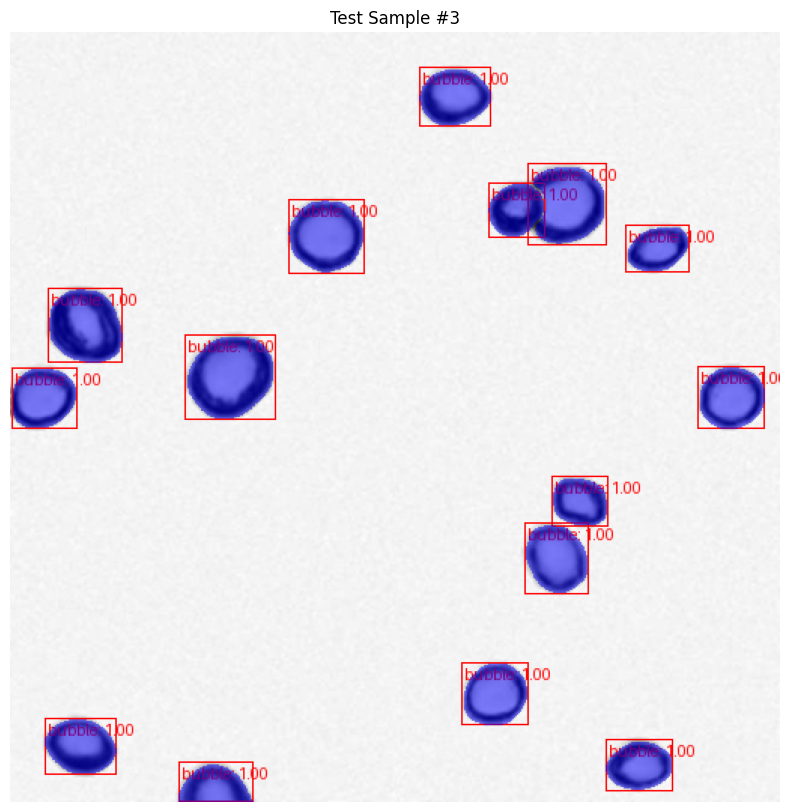

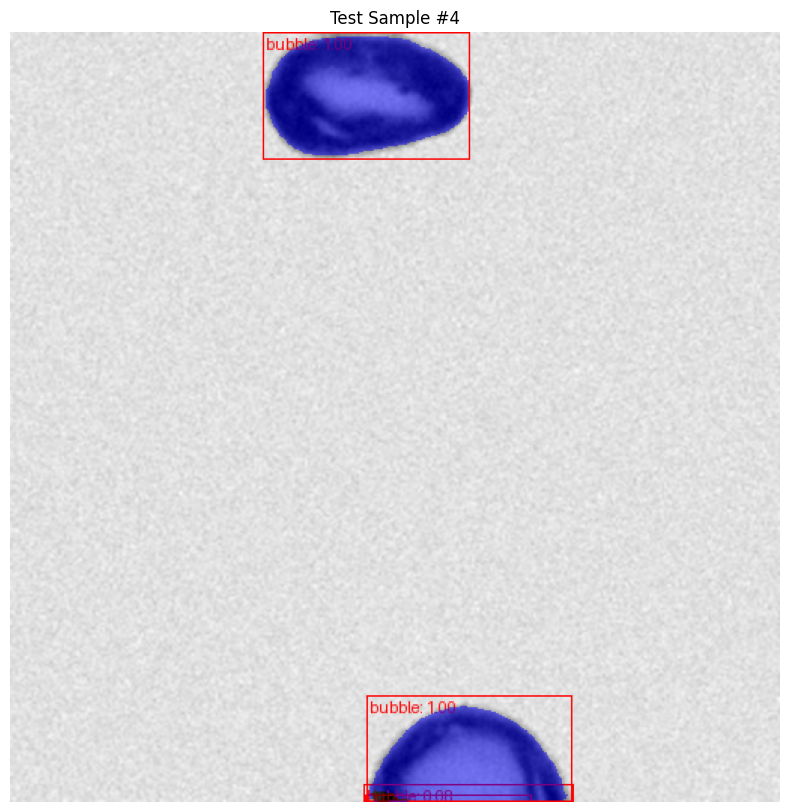

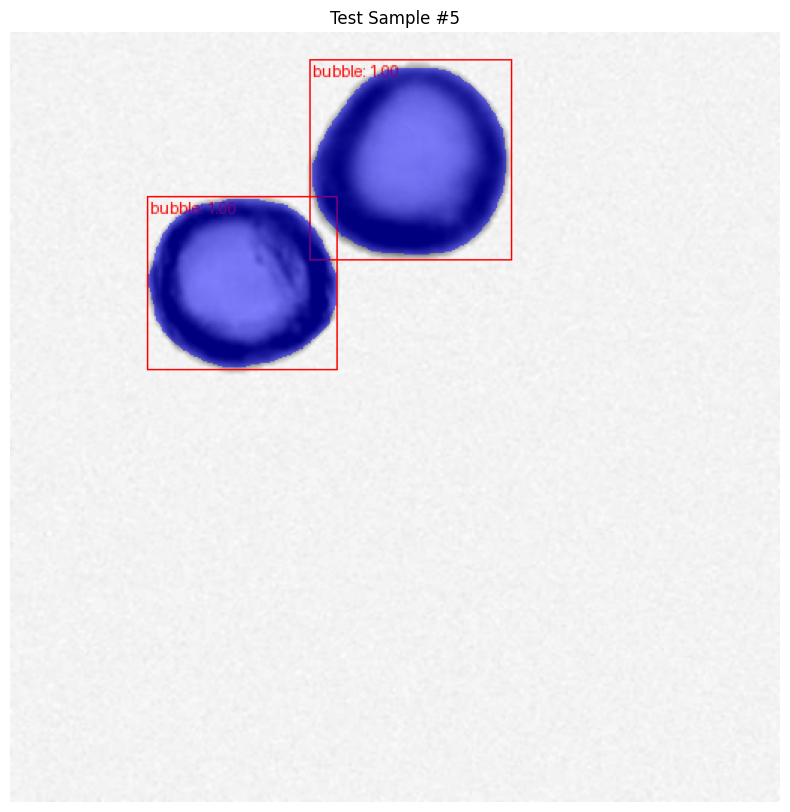

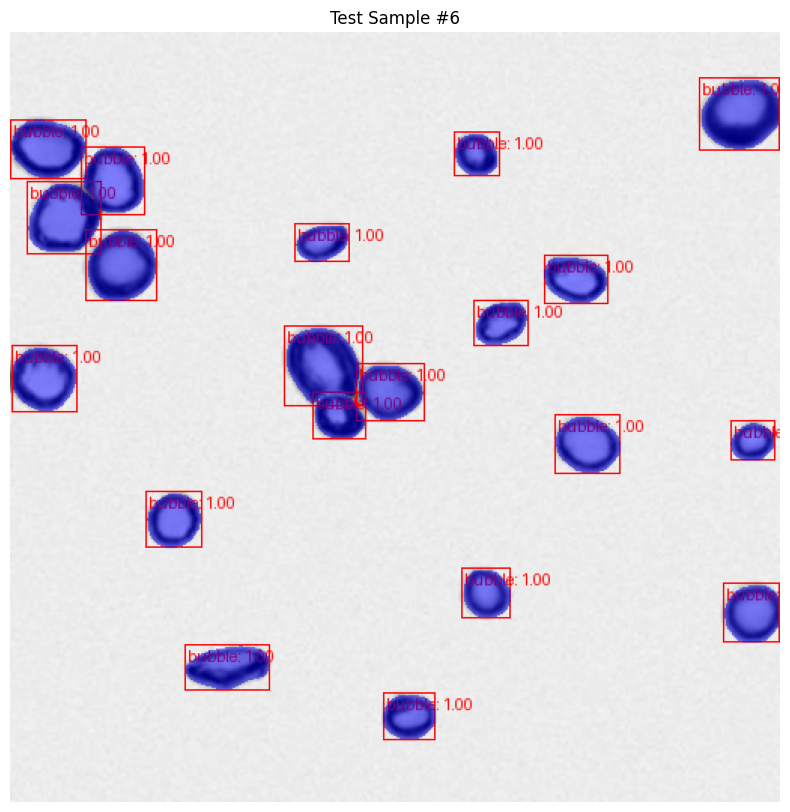

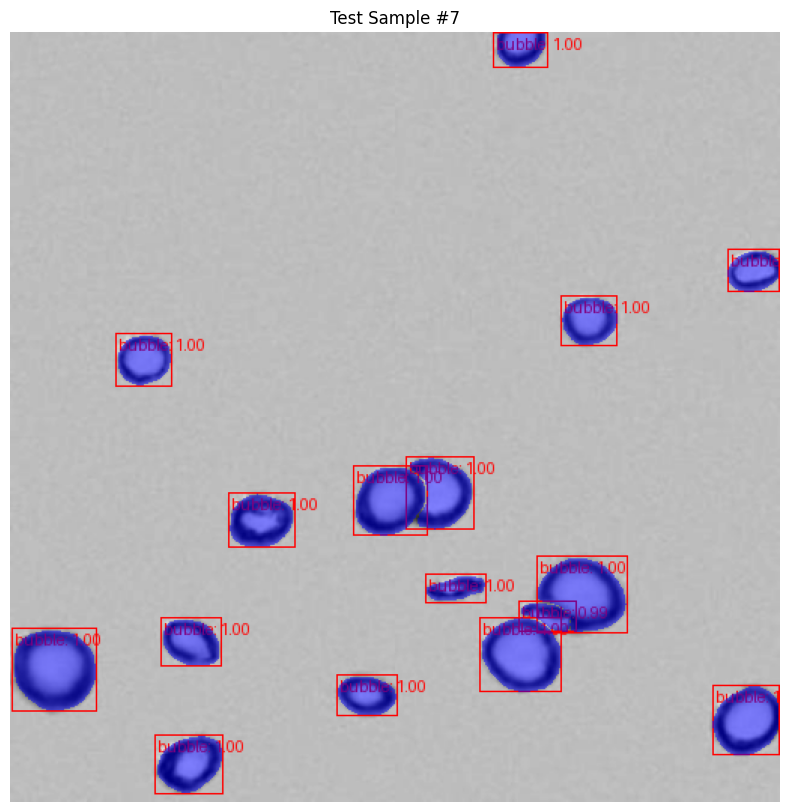

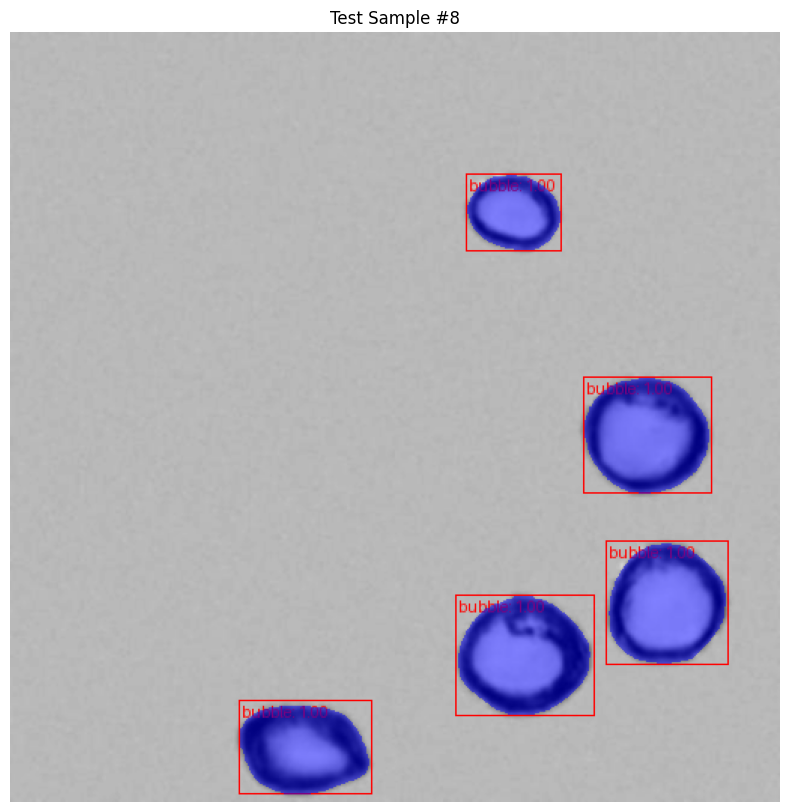

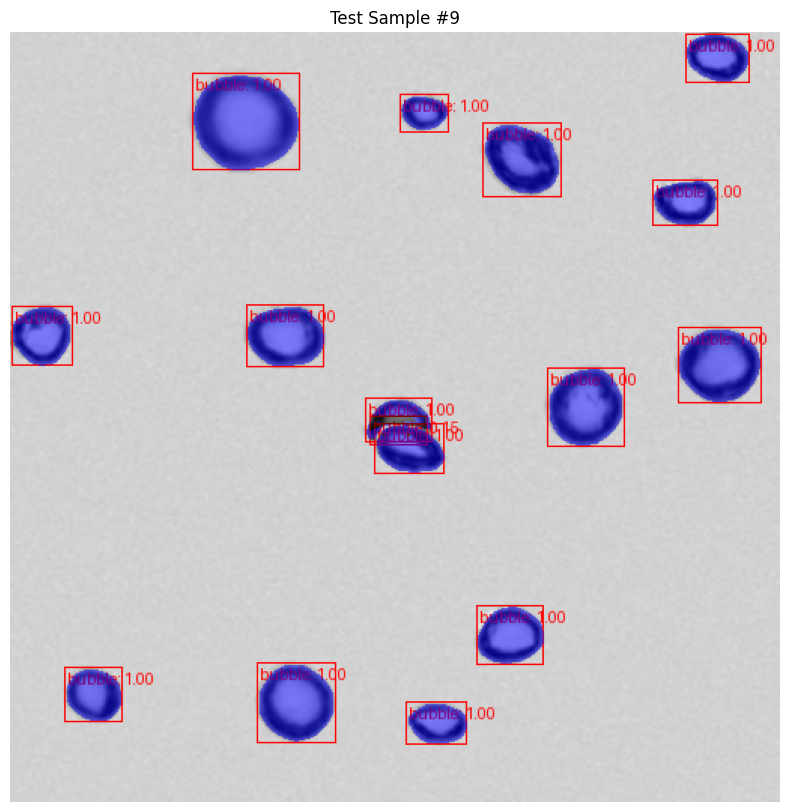

In [9]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as F
import torch

model.eval()

# Number of test images to visualize
N = 10

with torch.no_grad():
    for idx, (image, target) in enumerate(data_loader_test):
        if idx >= N:
            break

        x = image[0].to(device)  # batch size = 1
        x = x[:3, ...]  # Remove alpha channel if present

        pred = model([x])[0]




        # Rescale image for visualization
        x_cpu = x.cpu()
        vis_img = (255.0 * (x_cpu - x_cpu.min()) / (x_cpu.max() - x_cpu.min())).to(torch.uint8)

        pred_labels = [f"bubble: {score:.2f}" for score in pred["scores"]]
        pred_boxes = pred["boxes"].cpu().long()
        masks = (pred["masks"].cpu() > 0.7).squeeze(1)

        output_image = draw_bounding_boxes(vis_img, pred_boxes, pred_labels, colors="red")
        output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

        # Plot
        plt.figure(figsize=(10, 10))
        plt.imshow(output_image.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Test Sample #{idx}")
        plt.show()
